In [ ]:
#pip install opencv-python

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 
import os

In [1]:
def imagencolor():
 fotos=["Imagenes/3.jpeg","Imagenes/2.jpeg","Imagenes/1.jpeg"]
 totalc=[]
 totalt=[]
 for i in range(len(fotos)):
 ##img=cv2.imread("Imagenes/3.jpeg")
  #print(fotos[i])
  img=cv2.imread(fotos[i])
  gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  color=cv2.cvtColor(img,cv2.COLOR_RGBA2BGRA)
  colorg=cv2.cvtColor(gris,cv2.COLOR_RGBA2BGRA)
  color1=cv2.cvtColor(img,cv2.COLOR_RGB2YUV)
  color2=cv2.cvtColor(img,cv2.COLOR_RGB2HLS)
  color3=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
  c=[img,gris,color,colorg,color1,color2,color3]
  t=['Original Open cv','COLOR_BGR2GRAY','COLOR_RGBA2BGRA','GRAY_BGR','COLOR_RGB2YUV','COLOR_RGB2HLS','COLOR_BGR2HSV']
  #print(c,'\n', t)
  totalc.append(c)
  totalt.append(t)
  #print(len(totalt)) 
 return totalc,totalt
 


In [309]:
imagencolor()

([[array([[[195, 195, 195],
           [189, 189, 189],
           [181, 181, 181],
           ...,
           [195, 195, 195],
           [195, 195, 195],
           [195, 195, 195]],
   
          [[195, 195, 195],
           [163, 163, 163],
           [133, 133, 133],
           ...,
           [195, 195, 195],
           [195, 195, 195],
           [195, 195, 195]],
   
          [[195, 195, 195],
           [195, 195, 195],
           [120, 120, 120],
           ...,
           [195, 195, 195],
           [195, 195, 195],
           [195, 195, 195]],
   
          ...,
   
          [[195, 195, 195],
           [195, 195, 195],
           [195, 195, 195],
           ...,
           [195, 195, 195],
           [195, 195, 195],
           [195, 195, 195]],
   
          [[195, 195, 195],
           [195, 195, 195],
           [195, 195, 195],
           ...,
           [195, 195, 195],
           [195, 195, 195],
           [195, 195, 195]],
   
          [[195, 195, 195],
        

In [2]:
def mostrarcolor():
# #imagen=cv2.resize(gris,(img_size,img_size))
  c,t=imagencolor()
  for i in range(3):
   for j in range(7):
    imagen=cv2.resize(c[i][j],(150,150))
    plt.subplot(3,3,j+1)
    plt.imshow(c[i][j],vmin=0,vmax=255)
    plt.title(t[i][j])
    plt.xticks([])
    plt.yticks([])
   plt.show()

  

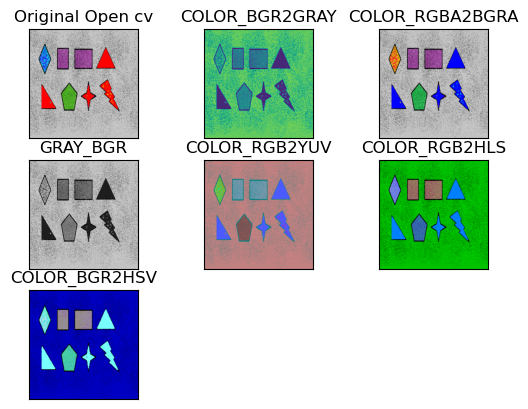

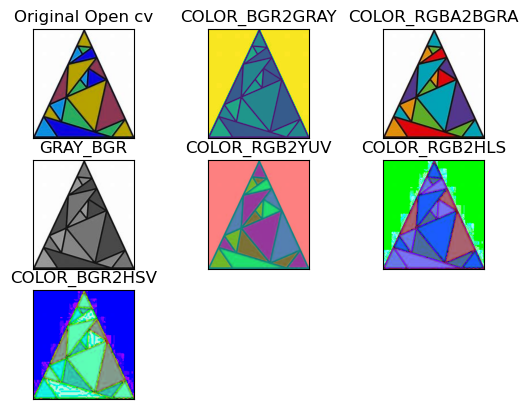

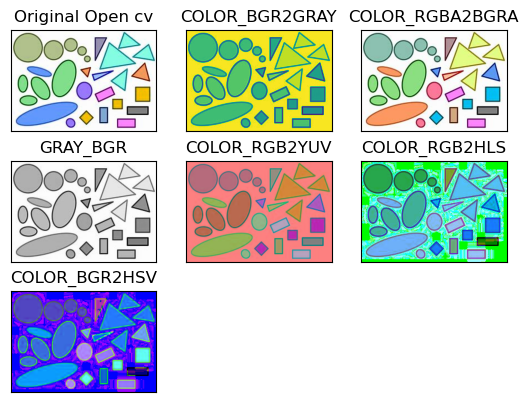

In [394]:
mostrarcolor()

## Aplicacion de suavisados de la imagen 

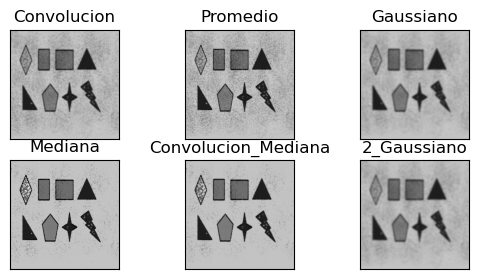

In [5]:
imagen=cv2.imread("Imagenes/3.jpeg") 
#Convercion de la imagen a Gray  y despues RGB 
imagen=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY) 
imagen=cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB) 
# capa de extracion de la imagen (crea una matriz )
kernel=np.ones((5,5),np.float32)/25
kernel1=np.ones((3,3),np.float32)/9
#Suavisado de convulucional 
Conv=cv2.filter2D(imagen,-1,kernel)
#Suavisado de promedio
Prom=cv2.blur(imagen,(3,3))
#Suavisado de gausiano 
Gaus=cv2.GaussianBlur(imagen,(15,15),0)
#Suavisado de Mediana 
Medi=cv2.medianBlur(imagen,3)
#Suavisado de Convinacin 
con_medi=cv2.filter2D(Medi,-1,kernel1)
Gaus_Gaus=cv2.GaussianBlur(Gaus,(5,5),0)
f=[Conv,Prom,Gaus,Medi,con_medi,Gaus_Gaus]
t=['Convolucion','Promedio','Gaussiano','Mediana','Convolucion_Mediana','2_Gaussiano']

for i in range(len(f)):
    imagen=cv2.resize(f[i],(150,150))
    plt.subplot(3,3,i+1)
    plt.imshow(f[i],vmin=0,vmax=255)
    plt.title(t[i])
    plt.xticks([])
    plt.yticks([])
plt.show()




In [12]:
#REALIZAR EL UNBRAL
#threshold(imagen,valor de color que quieres converir,color que deceas, aplicar la ubralizacion invertida  
#_,unbral=cv2.threshold(img,100,255,cv2.THRESH_BINARY_INV)
def Unbral():
 f=[Conv,Prom,Gaus,Medi,con_medi,Gaus_Gaus]
 t=['Convolucion','Promedio','Gaussiano','Mediana','Convolucion_Mediana','2_Gaussiano']
 u=[]
 u1=[]
 for i in range (len(f)):
    _,unbral=cv2.threshold(f[i],150,255,cv2.THRESH_BINARY_INV)
    _,unbralM=cv2.threshold(f[i],150,255,cv2.THRESH_BINARY)
    u.append(unbral)
    u1.append(unbralM)
 return u,u1,t





In [11]:
def mostrarunbral():
# #imagen=cv2.resize(gris,(img_size,img_size))
  u,u1,t=Unbral()
  for i in range(len(u)):
   for j in range(len(t)):
    imagen=cv2.resize(u[i],(150,150))
    plt.subplot(3,3,j+1)
    plt.imshow(u[i],vmin=0,vmax=255)
    plt.title(t[j])
    plt.xticks([])
    plt.yticks([])
   plt.show()

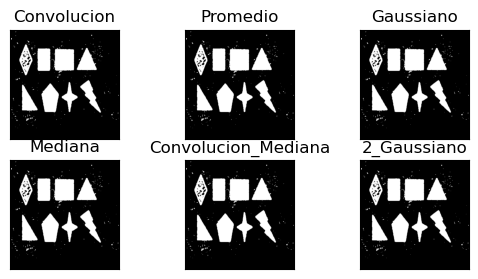

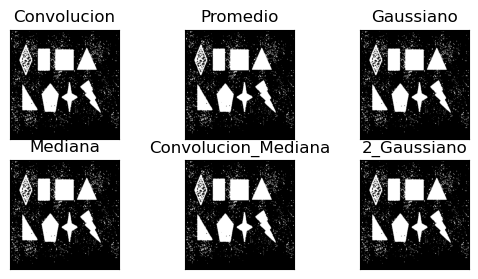

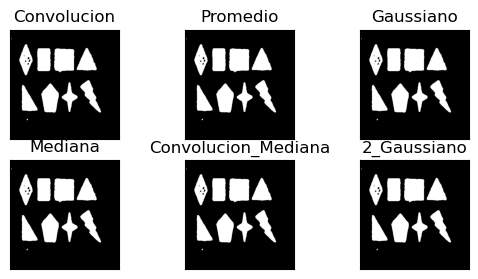

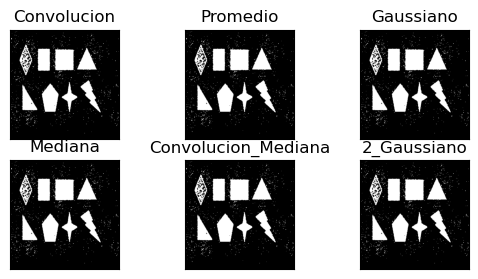

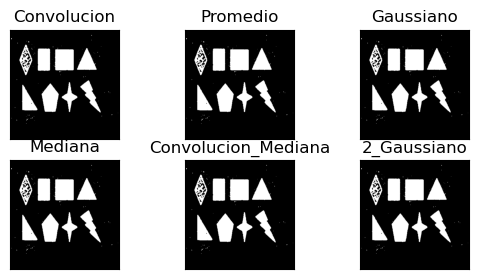

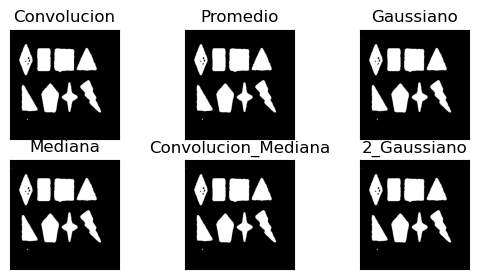

In [316]:
mostrarunbral()

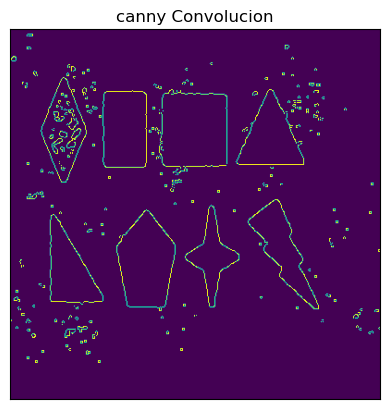

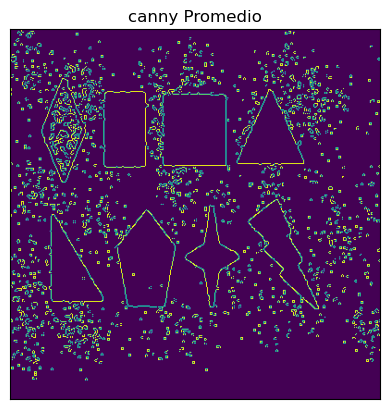

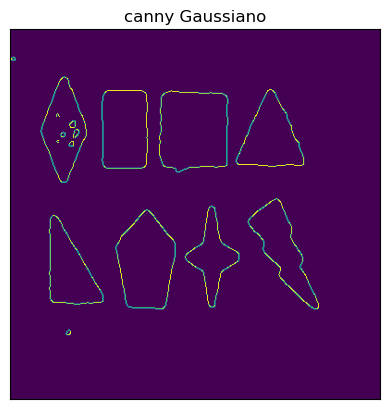

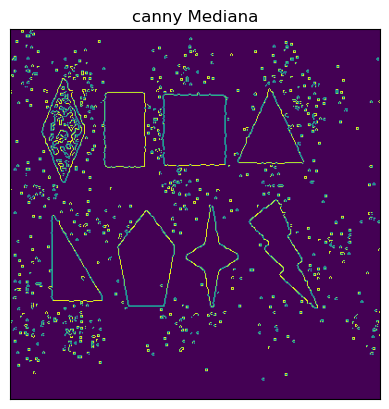

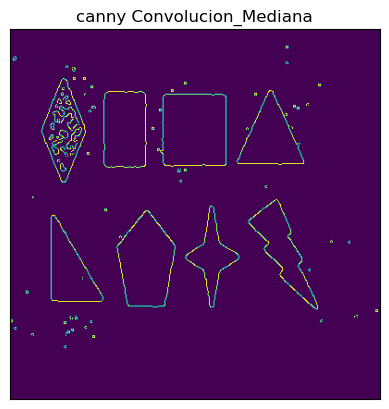

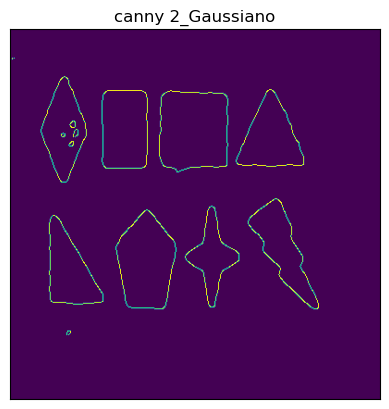

In [328]:
u,u1,t=Unbral()
for i in range(len(u)):
 canny=cv2.Canny(u[i],120,255)
#cv2.imshow('canny',canny)
#cv2.waitKey(0)
 plt.imshow(canny,vmin=0,vmax=255)
 plt.title('canny '+t[i])
 plt.xticks([])
 plt.yticks([])
 plt.show()

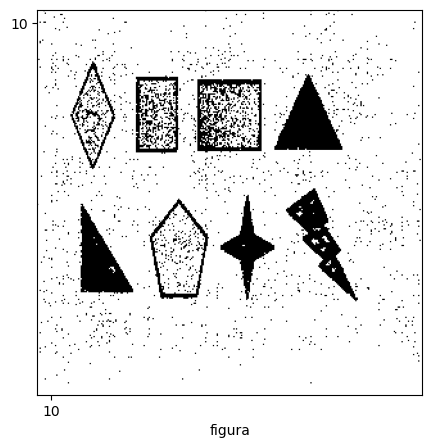

1616


In [5]:

imagen_o=cv2.imread("Imagenes/3.jpeg") 
imagen_o=cv2.resize(imagen_o,(300,300))
gris=cv2.cvtColor(imagen_o,cv2.COLOR_BGR2GRAY)
imagen_g=cv2.resize(gris,(300,300))

_,unbra=cv2.threshold(imagen_g,100,255,cv2.THRESH_BINARY,cv2.THRESH_OTSU)
#Encontrar contorno 
# Modos 
#RETR_EXTERNAL,RETR_TREE,RETR_FLOODFILL,RETR_LIST
#Conteo de puntos 
#cv2.CHAIN_APPROX_SIMPLE,cv2.CHAIN_APPROX_NONE

#contorno,_ =cv2.findContours(unbra,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contorno,_ =cv2.findContours(unbra,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
#contorno,_ =cv2.findContours(unbra,cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)


gris=cv2.cvtColor(unbra,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.xticks([10])
plt.yticks([10])
plt.imshow(gris)
plt.xlabel('figura')
plt.show()
print(len(contorno))
lista_area=[]

In [6]:
#Dibujar contorno 
lista_area=[]
for i in range(len(contorno)):
 area=cv2.contourArea(contorno[i])
 lista_area.append(area)
 cv2.drawContours(imagen_o,contorno,1,(0,0,255,),3)
 cv2.imshow('siluetas',imagen_o)
 lista_area=[]
cv2.waitKey(0)
cv2.destroyAllWindows()

In [8]:
img_E = np.zeros((512, 512, 3), np.uint8)
img_E = cv2.line(img_E, (0, 0), (500, 500), (255, 0, 0), 5)
img_E = cv2.circle(img_E, (447,63), 63, (0,0,255), -1)
img_E = cv2.ellipse(img_E, (100,200), (30,30), 0, 0, 180, 255, -1)

cv2.imshow('image',img_E)
cv2.waitKey(0)
cv2.destroyAllWindows()